# UMAP + HDBSCAN for RBD Downsampled(Alpha, Delta, Omicron)

Embedded using ESM2 8M model. Finetuned (NOT base model).

In [ ]:
version_dir = "rbd_o_finetuned"
version_prefix = "RBD.O.from-esm-mlm_CLS-embedded"

In [3]:
import os
import pandas as pd

data_dir = "/panfs/biopan03/prime_ml/prime/data/rbd/old"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/parquets"

parquet_file = os.path.join(data_dir, "spikeprot0528.clean.uniq.noX.RBD.metadata.variants.O_from-esm-mlm_CLS-embedded.parquet")
embedded_o_df = pd.read_parquet(parquet_file, engine='fastparquet')

print(embedded_o_df['variant'].value_counts())
display(embedded_o_df)

variant
Omicron    160016
Name: count, dtype: int64


,seq_id,variant,Pango lineage,Location,Collection date,AA Substitutions,embedding
0,EPI_ISL_14904955,Omicron,BA.5.5,North America / USA / Maryland,2022-08-22,"(NSP5_P132H,Spike_H69del,NSP3_G489S,Spike_L24d...","[-0.044596042, 0.46855015, 0.4777561, 0.526366..."
1,EPI_ISL_14904971,Omicron,BA.5.6,North America / USA / California,2022-08-22,"(NSP5_P132H,Spike_H69del,NSP3_G489S,Spike_L24d...","[-0.044596042, 0.46855015, 0.4777561, 0.526366..."
2,EPI_ISL_14906096,Omicron,BA.5.1.10,North America / USA / New York,2022-08-27,"(NSP5_P132H,Spike_H69del,NSP3_G489S,Spike_L24d...","[-0.044596042, 0.46855015, 0.4777561, 0.526366..."
3,EPI_ISL_14906051,Omicron,BA.5.2.18,North America / USA / Maryland,2022-08-27,"(NSP5_P132H,Spike_P809T,Spike_H69del,NSP3_G489...","[-0.025544459, 0.49064007, 0.466701, 0.5338042..."
4,EPI_ISL_14906040,Omicron,BA.5.2.9,North America / USA / Michigan,2022-08-26,"(NSP5_P132H,Spike_H69del,Spike_A67V,NSP3_G489S...","[-0.044596042, 0.46855015, 0.4777561, 0.526366..."
...,...,...,...,...,...,...,...
160011,EPI_ISL_12987713,Omicron,BA.2.10,Asia / Japan / Hyogo,2022-05-03,"(NSP5_P132H,NSP3_G489S,Spike_L24del,NSP4_T327I...","[-0.07653996, 0.38558048, 0.36135942, 0.600124..."
160012,EPI_ISL_14903692,Omicron,BF.5,North America / USA / California / Alameda County,2022-07-30,"(NSP5_P132H,Spike_H69del,Spike_L24del,NSP3_G48...","[-0.044596102, 0.46855125, 0.47775534, 0.52636..."
160013,EPI_ISL_14902388,Omicron,BA.4.6,North America / USA / California,2022-08-22,"(NSP5_P132H,Spike_H69del,Spike_N658S,NSP3_G489...","[-0.054073125, 0.503786, 0.5165994, 0.55572003..."
160014,EPI_ISL_14905423,Omicron,BA.5.6,North America / USA / New Jersey,2022-08-22,"(NSP5_P132H,Spike_H69del,Spike_H1058Y,NSP3_G48...","[-0.044596102, 0.46855125, 0.47775534, 0.52636..."


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import cupy as cp
from cuml.cluster import HDBSCAN
from cuml.preprocessing import LabelEncoder
from cuml.metrics.cluster import adjusted_rand_score, silhouette_score

def get_coord_cols(df):
    if {"t-SNE component 1", "t-SNE component 2"}.issubset(df.columns):
        return "t-SNE component 1", "t-SNE component 2", "t-SNE"
    elif {"UMAP 1", "UMAP 2"}.issubset(df.columns):
        return "UMAP 1", "UMAP 2", "UMAP"
    else:
        raise ValueError("Could not find t-SNE or UMAP coordinate columns.")

def get_hdbscan_values(parquet_file, min_samples, min_cluster_size):
    embedded_df = pd.read_parquet(parquet_file, engine="fastparquet")
    x_col, y_col, method_name = get_coord_cols(embedded_df)
    
    # CPU -> GPU
    embedding_matrix = embedded_df[[x_col, y_col]].values.astype(np.float32)
    X_gpu = cp.asarray(embedding_matrix)

    y_true = LabelEncoder().fit_transform(embedded_df["Variant"].values)
    y_true_gpu = cp.asarray(y_true)

    # GPU HDBSCAN
    clusterer = HDBSCAN(
        min_samples=min_samples,
        min_cluster_size=min_cluster_size,
    )

    labels_gpu = clusterer.fit_predict(X_gpu)

    # GPU metrics
    ari = float(adjusted_rand_score(y_true_gpu, labels_gpu))

    valid_cluster_labels = labels_gpu[labels_gpu != -1]
    n_clusters = int(cp.unique(valid_cluster_labels).size)

    if n_clusters > 1:
        silhouette_avg = float(silhouette_score(X_gpu, labels_gpu, metric="cosine"))
    else:
        silhouette_avg = np.nan

    noise_fraction = float(cp.mean(labels_gpu == -1))

    print(
        f"min_samples = {min_samples}, "
        f"min_cluster_size = {min_cluster_size}: "
        f"ARI = {ari:.2f}, "
        f"Silhouette = {silhouette_avg:.2f}, "
        f"Clusters = {n_clusters}, "
        f"Noise = {noise_fraction:.2%}"
    )

    # GPU -> CPU for pandas
    labels = cp.asnumpy(labels_gpu)

    truth_table_percent = pd.crosstab(
        embedded_df["Variant"],
        labels,
        rownames=["Ground Truth"],
        colnames=["Predicted Clusters"],
        normalize="index",
    )
    truth_table_percent = (truth_table_percent * 100).round(2)

    plot_df = pd.DataFrame({
        x_col: embedded_df[x_col].values,
        y_col: embedded_df[y_col].values,
        "Cluster": labels,
        "Seq ID": embedded_df["Seq ID"].values,
        "Variant": embedded_df["Variant"].values,
        "Pango lineage": embedded_df["Pango lineage"].values,
        "Collection date": embedded_df["Collection date"].values,
    })

    save_as = parquet_file.replace(
        ".parquet",
        f".HDBSCAN-ms{min_samples}_mcs{min_cluster_size}-ari{ari:.2f}_sc{silhouette_avg:.2f}_noise{noise_fraction:.2f}"
    )
    plot_df.to_parquet(f"{save_as}.parquet", engine="fastparquet", index=False)

    del X_gpu, labels_gpu
    cp.get_default_memory_pool().free_all_blocks()

    return plot_df, truth_table_percent, save_as

def plot_groundtruth_prediction_1x2(plot_df, save_as, plot_dir, x_min_width_buffer, x_max_width_buffer, y_min_width_buffer, y_max_width_buffer, color_map, cluster_color_palette_order=None):
    marker_size = 25
    
    # Define a variant color palette
    unique_variants = np.unique(plot_df['Variant'])
    variant_color_palette = sns.color_palette(color_map, n_colors=len(unique_variants)) 
    variant_color_dict = {label: color for label, color in zip(unique_variants, variant_color_palette)}

    # Define a cluster color palette
    unique_clusters = np.unique(plot_df["Cluster"])
    non_noise_clusters = unique_clusters[unique_clusters != -1]

    cluster_color_palette = sns.color_palette(color_map, n_colors=len(non_noise_clusters))

    if cluster_color_palette_order is not None:
        cluster_color_palette = [cluster_color_palette[i] for i in cluster_color_palette_order]

    cluster_color_dict = {label: color for label, color in zip(non_noise_clusters, cluster_color_palette)}
    cluster_color_dict[-1] = 'black'  # Set outliers to x

    sns.set_style('ticks')
    sns.set_context("poster")
    fig, axs = plt.subplots(1, 2, figsize=(20.25, 6.5), sharey=True)
    fig.subplots_adjust(wspace=0.05)  # Reduce the horizontal space between subplots

    x_col, y_col, method_name = get_coord_cols(plot_df)
    #####################################################

    # Scatterplot
    sns.scatterplot(
        data=plot_df,
        x=x_col, y=y_col,
        hue='Variant', palette=variant_color_dict, 
        s=marker_size, alpha=0.5, edgecolor=None, linewidth=1,
        ax=axs[0]
    )

    # axs[0].set_title(f"Ground Truth ({len(unique_variants)} variants)", ha='center', fontweight='bold')
    axs[0].set_xlim((plot_df[x_col].min()-x_min_width_buffer, plot_df[x_col].max()+x_max_width_buffer))
    axs[0].set_ylim(plot_df[y_col].min()-y_min_width_buffer, plot_df[y_col].max()+y_max_width_buffer),

    # Legend 
    variant_handles = [
        plt.Line2D([0], [0], color=variant_color_dict[variant], label=f'{variant}')
        for variant in unique_variants
    ]
    axs[0].legend(handles=variant_handles)
    sns.move_legend(axs[0], "upper right", fontsize=14)
    
    # #####################################################

    # Scatterplot for non-outliers
    sns.scatterplot(
        data=plot_df[plot_df['Cluster'] != -1],  # Exclude outliers
        x=x_col, y=y_col,
        hue='Cluster', palette=cluster_color_dict, 
        s=marker_size, alpha=0.5, edgecolor=None, linewidth=1,
        ax=axs[1]
    )

    # Scatterplot for outliers (Cluster = -1)
    sns.scatterplot(
        data=plot_df[plot_df['Cluster'] == -1],  # Select only outliers
        x=x_col, y=y_col,
        marker='x',
        s=marker_size*2, color='black', linewidth=2,
        ax=axs[1]
    )

    # axs[1].set_title(f"Predicted ({len(unique_clusters[unique_clusters != -1])} clusters)", ha='center', fontweight='bold')
    axs[1].set_xlim((plot_df[x_col].min()-x_min_width_buffer, plot_df[x_col].max()+x_max_width_buffer))

    # Legend 
    cluster_handles = [plt.Line2D([0], [0], marker='x', color='black', linestyle='none', label='Outliers')]
    cluster_handles += [
        plt.Line2D([0], [0], color=cluster_color_dict[cluster], label=f'Cluster {cluster}')
        for cluster in unique_clusters if cluster != -1
    ]
    axs[1].legend(handles=cluster_handles)
    sns.move_legend(axs[1], "upper right", fontsize=14)

    #####################################################
    base = os.path.splitext(os.path.basename(save_as))[0]  
    filename = f"{base}"
    
    save_as = os.path.join(plot_dir, filename)  
    plt.savefig(f"{save_as}.pdf", format="pdf", dpi=300, bbox_inches='tight')
    plt.savefig(f"{save_as}.png", format="png", dpi=300, bbox_inches='tight')
    plt.show()

In [5]:
import matplotlib.dates as mdates

def cluster_pango_lineage(plot_df, top_x=None):
    """ Calculate Pango lineage percentages within clusters and select top x for each cluster. """
    
    # Copy the DataFrame to avoid modifying the original
    df = plot_df.copy()

    # Truncate Pango lineage to the first two parts if needed
    trunc_format = lambda x: f"{'.'.join(x.split('.')[:3])}*" if len(x.split('.')) >= 3 else x
    df['Pango lineage'] = df['Pango lineage'].apply(trunc_format)

    # Calculate lineage counts within each cluster
    cluster_counts = df.groupby(['Cluster', 'Variant', 'Pango lineage']).size().reset_index(name='Cluster count')

    # Calculate total counts for each lineage across the entire dataset
    total_counts = df.groupby('Pango lineage').size().reset_index(name='Total count')

    # Merge the cluster counts with total counts
    lineage_counts = pd.merge(cluster_counts, total_counts, on='Pango lineage', how='left')

    # Calculate the 'Cluster %' and 'Lineage %'
    lineage_counts['Cluster %'] = (lineage_counts['Cluster count'] / lineage_counts.groupby('Cluster')['Cluster count'].transform('sum')) * 100
    lineage_counts['Lineage %'] = (lineage_counts['Cluster count'] / lineage_counts['Total count']) * 100

    # Sort by 'cluster' and then by 'Cluster %' within each cluster
    lineage_counts = lineage_counts.sort_values(by=['Cluster', 'Cluster %'], ascending=[True, False])
    lineage_counts = lineage_counts.drop(columns=['Cluster count', 'Total count'])

    # Select top x lineages for each cluster
    if top_x != None:
        top_lineages_per_cluster = lineage_counts.groupby('Cluster').head(top_x)
        return top_lineages_per_cluster.reset_index(drop=True)
    else:
        return lineage_counts.reset_index(drop=True)

def split_dataframe_by_cluster(df):
    """ Split the DataFrame into separate DataFrames by cluster. """
    
    # Create a dictionary to store DataFrames for each cluster
    cluster_dfs = {}
    
    # Group the DataFrame by 'cluster' and iterate over each group
    for cluster, group in df.groupby('Cluster'):
        # Store each group as a separate DataFrame in the dictionary
        cluster_dfs[cluster] = group.reset_index(drop=True)
    
    return cluster_dfs

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def ari_sc_heatmap(results_df, save_as, plot_dir):

    # Convert to DataFrame
    df = results_df.copy()

    # Pivot matrices
    ari_matrix = df.pivot(index='min_samples', columns='min_cluster_size', values='ari')
    silhouette_matrix = df.pivot(index='min_samples', columns='min_cluster_size', values='silhouette')

    # Plot heatmaps
    sns.set_style('ticks')
    sns.set_context("talk")
    fig, axs = plt.subplots(2, 1, figsize=(20, 20))

    sns.heatmap(ari_matrix, annot=True, annot_kws={"size": 16}, fmt=".2f", linewidth=.5, cmap="RdBu", ax=axs[0], vmin=-0.19, vmax=1)
    axs[0].set_title("Adjusted Rand Index (ARI)")
    axs[0].set_xlabel("min_cluster_size")
    axs[0].set_ylabel("min_samples")

    max_ari = ari_matrix.max().max()  # Get the max ARI value

    for i in range(ari_matrix.shape[0]):  # min_sample (rows)
        for j in range(ari_matrix.shape[1]):  # min_cluster_size (cols)
            if np.isclose(ari_matrix.iloc[i, j], max_ari):  # Safe float comparison
                axs[0].add_patch(
                    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=3)
                )

    sns.heatmap(silhouette_matrix, annot=True, annot_kws={"size": 16}, fmt=".2f", linewidth=.5, cmap="RdBu", ax=axs[1], vmin=-0.19, vmax=1)
    axs[1].set_title("Silhouette Coefficient")
    axs[1].set_xlabel("min_cluster_size")
    axs[1].set_ylabel("min_samples")

    for i in range(ari_matrix.shape[0]):  # min_samples (rows)
        for j in range(ari_matrix.shape[1]):  # min_cluster_size (cols)
            if np.isclose(ari_matrix.iloc[i, j], max_ari):  # Safe float comparison
                axs[1].add_patch(
                    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=3)
                )

    base = os.path.splitext(os.path.basename(parquet_file))[0]
    filename = f"{base}.HDBSCAN_heatmap"
    
    save_as = os.path.join(plot_dir, filename)
    plt.savefig(f"{save_as}.pdf", format="pdf", dpi=300, bbox_inches='tight')
    plt.savefig(f"{save_as}.png", format="png", dpi=300, bbox_inches='tight')

    plt.show()

---
### Parameter sweep for UMAP/TSNE + HDBSCAN
Apply UMAP to the embeddings, then save the UMAP embeddings. 

We adjust our parameter sweep to include noise fraction. This is the proportion of points that HDBSCAN labels as noise/outliers, meaning they are not assigned to any cluster.

For example: If you have 100 sequences and HDBSCAN labels:
- 80 into clusters
- 20 as -1
- Then: noise_fraction = 20 / 100 = 0.20. This results in a noise_fraction of 0.2, or 20% of the data!

Why does it matter?
| Noise fraction | Interpretation                                  |
| -------------- | ----------------------------------------------- |
| Low            | most points were assigned to clusters           |
| Moderate       | HDBSCAN is being selective                      |
| High           | many points do not fit well into dense clusters |

This will allow us to better make sense of our ARI scores. Some scenarios to help make better sense:
| ARI  | Noise fraction | Interpretation                             |
| ---- | -------------- | ------------------------------------------ |
| High | Low            | Strong result                              |
| High | Very high      | Maybe only a subset clustered well         |
| Low  | High           | Clustering may be too strict               |
| Low  | Low            | Clustering may be forcing poor assignments |

And a more specific example:
| Setting | ARI  | Noise fraction |
| ------- | ---- | -------------- |
| A       | 0.82 | 0.08           |
| B       | 0.83 | 0.47           |

I would usually trust A more, because B is discarding almost half the dataset.

---
## UMAP
(doc: https://docs.rapids.ai/api/cuml/stable/api/generated/cuml.manifold.umap/#cuml.manifold.UMAP)

Some more on parameters for UMAP:
- https://umap-learn.readthedocs.io/en/latest/parameters.html
- https://pair-code.github.io/understanding-umap/

In [7]:
import os
from sklearn.model_selection import ParameterGrid
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

import cupy as cp
from cuml.manifold import UMAP
from cuml.cluster import HDBSCAN
from cuml.preprocessing import LabelEncoder
from cuml.metrics.cluster import adjusted_rand_score, silhouette_score

def umap_hdbscan_parameter_sweep(parquet_file, embedded_df, n_neighbors_list, min_dist_list, min_samples_list, min_cluster_size_list):
    umap_grid = {
        "n_neighbors": n_neighbors_list,
        "min_dist": min_dist_list,
    }
    umap_param_list = list(ParameterGrid(umap_grid))

    hdbscan_grid = {
        "min_samples": min_samples_list,
        "min_cluster_size": min_cluster_size_list,
    }
    hdbscan_param_list = list(ParameterGrid(hdbscan_grid))

    all_results = []

    # CPU -> GPU
    embedding_matrix = np.vstack(embedded_df["embedding"].values).astype(np.float32)
    X_gpu = cp.asarray(embedding_matrix)
    y_true = LabelEncoder().fit_transform(embedded_df["variant"].values)
    y_true_gpu = cp.asarray(y_true)

    # Parameter Sweep (UMAP)
    for umap_params in tqdm(umap_param_list, desc="UMAP sweep"):
        reducer = UMAP(
            n_neighbors=umap_params["n_neighbors"],
            min_dist=umap_params["min_dist"],
            metric="cosine",
            random_state=42,
        )
        X_red = reducer.fit_transform(X_gpu)
        X_red_cpu = cp.asnumpy(X_red)

        umap_df = pd.DataFrame({
            'UMAP 1': X_red_cpu[:, 0],
            'UMAP 2': X_red_cpu[:, 1],
            'Seq ID': embedded_df['seq_id'].values,
            'Variant': embedded_df['variant'].values,
            'Pango lineage': embedded_df['Pango lineage'].values,
            'Collection date': embedded_df['Collection date'].values
        })
        save_as = parquet_file.replace(".parquet", f".umap-nneighbors{umap_params["n_neighbors"]}_mindist{umap_params["min_dist"]}.parquet")
        umap_df.to_parquet(save_as, engine='fastparquet')

        # Parameter Sweep (HDBSCAN)
        for hdbscan_params in tqdm(hdbscan_param_list, leave=False):
            clusterer = HDBSCAN(
                min_samples=hdbscan_params["min_samples"],
                min_cluster_size=hdbscan_params["min_cluster_size"],
            )

            labels = clusterer.fit_predict(X_red)
            ari = float(adjusted_rand_score(y_true_gpu, labels))
            noise_fraction = float(cp.mean(labels == -1))

            non_noise_mask = labels != -1
            valid_cluster_labels = labels[non_noise_mask]
            
            n_non_noise_samples = int(cp.sum(non_noise_mask))
            n_non_noise_clusters = int(cp.unique(valid_cluster_labels).size)

            # silhouette needs at least two clusters AND
            # avoids the case where every non-noise point is its own cluster
            if n_non_noise_clusters > 1 and n_non_noise_samples > n_non_noise_clusters:
                silhouette_avg = float(silhouette_score(X_red[non_noise_mask], valid_cluster_labels,  metric="cosine"))
            else:
                silhouette_avg = np.nan            

            all_results.append({
                "n_neighbors": umap_params["n_neighbors"],
                "min_dist": umap_params["min_dist"],
                "min_samples": hdbscan_params["min_samples"],
                "min_cluster_size": hdbscan_params["min_cluster_size"],
                "ari": ari,
                "noise_fraction": noise_fraction,
                "silhouette": silhouette_avg,
                "n_clusters": n_non_noise_clusters,
            })
            
        # cleanup
        del X_red
        cp._default_memory_pool.free_all_blocks()

    # Final results of both parameter sweeps
    full_results_df = pd.DataFrame(all_results) # All results
    return full_results_df

/panfs/biopan03/prime_ml/miniconda3/envs/blackwell_prime/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
%%time

sweep_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/param_sweeps"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/parquets"

umap_grid = {
    "n_neighbors": [10, 15, 30, 50, 75, 100],
    "min_dist": [0.0, 0.1, 0.15, 0.25, 0.5, 0.75, 1.0],
}

hdbscan_grid = {
    "min_samples": [10, 25, 50, 100, 250, 500, 1000], # cuml HDBSCAN blocks min_samples above 1023
    "min_cluster_size": [50, 100, 250, 500, 1000, 2500, 5000, 10000, 15000, 20000, 22000],
}

parquet_file = os.path.join(data_dir, "spikeprot0528.clean.uniq.noX.RBD.metadata.variants.O_from-esm-mlm_CLS-embedded.parquet")
embedded_df = pd.read_parquet(os.path.join(data_dir, parquet_file), engine="fastparquet")

parquet_file_name = os.path.join(parquet_dir, version_dir, f"{version_prefix}.parquet")

full_results_umap_df = umap_hdbscan_parameter_sweep(
    os.path.join(parquet_dir, version_dir, parquet_file_name),
    embedded_df, 
    umap_grid["n_neighbors"],
    umap_grid["min_dist"],
    hdbscan_grid["min_samples"],
    hdbscan_grid["min_cluster_size"],
)

full_results_umap_df.to_csv(os.path.join(sweep_dir, version_dir, f"{version_prefix}-umap_hdbscan-parameter_sweep.csv"), index=False)

UMAP sweep: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [2:00:16<00:00, 171.81s/it]

CPU times: user 1h 17min 52s, sys: 23min, total: 1h 40min 52s
Wall time: 2h 27s


Base:

In [18]:
%%time

version_dir = "rbd_o_base"
version_prefix = "RBD.O.CLS-embedded"

sweep_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/param_sweeps"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/parquets"

umap_grid = {
    "n_neighbors": [10, 15, 30, 50, 75, 100],
    "min_dist": [0.0, 0.1, 0.15, 0.25, 0.5, 0.75, 1.0],
}

hdbscan_grid = {
    "min_samples": [10, 25, 50, 100, 250, 500, 1000], # cuml HDBSCAN blocks min_samples above 1023
    "min_cluster_size": [50, 100, 250, 500, 1000, 2500, 5000, 10000, 15000, 20000, 22000],
}

parquet_file = os.path.join(data_dir, "spikeprot0528.clean.uniq.noX.RBD.metadata.variants.O_CLS-embedded.parquet")
embedded_df = pd.read_parquet(os.path.join(data_dir, parquet_file), engine="fastparquet")

parquet_file_name = os.path.join(parquet_dir, version_dir, f"{version_prefix}.parquet")

full_results_umap_df = umap_hdbscan_parameter_sweep(
    os.path.join(parquet_dir, version_dir, parquet_file_name),
    embedded_df, 
    umap_grid["n_neighbors"],
    umap_grid["min_dist"],
    hdbscan_grid["min_samples"],
    hdbscan_grid["min_cluster_size"],
)

full_results_umap_df.to_csv(os.path.join(sweep_dir, version_dir, f"{version_prefix}-umap_hdbscan-parameter_sweep.csv"), index=False)

UMAP sweep: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [1:41:49<00:00, 145.46s/it]

CPU times: user 1h 20min 45s, sys: 14min 57s, total: 1h 35min 43s
Wall time: 1h 41min 55s


In [19]:
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden to 1 by setting random_state")

from sklearn.model_selection import ParameterGrid
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

import cupy as cp
from cuml.manifold import TSNE
from cuml.cluster import HDBSCAN
from cuml.preprocessing import LabelEncoder
from cuml.metrics.cluster import adjusted_rand_score, silhouette_score

def tsne_hdbscan_parameter_sweep(parquet_file, embedded_df, perplexity_list, min_samples_list, min_cluster_size_list):
    hdbscan_grid = {
        "min_samples": min_samples_list,
        "min_cluster_size": min_cluster_size_list,
    }
    hdbscan_param_list = list(ParameterGrid(hdbscan_grid))

    all_results = []

    # CPU -> GPU
    embedding_matrix = np.vstack(embedded_df["embedding"].values).astype(np.float32)
    X_gpu = cp.asarray(embedding_matrix)
    y_true = LabelEncoder().fit_transform(embedded_df["variant"].values)
    y_true_gpu = cp.asarray(y_true)

    n_samples = X_gpu.shape[0]
    early_exaggeration = 24.0 if n_samples > 10000 else 12.0 # Default 12.0
    learning_rate = max(n_samples / early_exaggeration, 200) # Default: 200

    # Parameter Sweep (TSNE)
    for perp in tqdm(perplexity_list, desc="TSNE sweep"):
        reducer = TSNE(
            n_components=2,
            perplexity=perp,
            n_neighbors=3 * perp,   # recommended by cuml, caps at 1023
            init="pca",             # like openTSNE
            metric="cosine",
            method="fft",
            random_state=42,
            early_exaggeration=early_exaggeration,
            learning_rate=learning_rate,
            learning_rate_method=None,
        )
        X_red = reducer.fit_transform(X_gpu)
        X_red_cpu = cp.asnumpy(X_red)

        # Save 
        tsne_df = pd.DataFrame({
            't-SNE component 1': X_red_cpu[:, 0],
            't-SNE component 2': X_red_cpu[:, 1],
            'Seq ID': embedded_df['seq_id'].values,
            'Variant': embedded_df['variant'].values,
            'Pango lineage': embedded_df['Pango lineage'].values,
            'Collection date': embedded_df['Collection date'].values
        })
        save_as = parquet_file.replace(".parquet", f".tsne-perplexity{perp}.parquet")
        tsne_df.to_parquet(save_as, engine='fastparquet')

        # Parameter Sweep (HDBSCAN)
        for hdbscan_params in tqdm(hdbscan_param_list, leave=False):
            clusterer = HDBSCAN(
                min_samples=hdbscan_params["min_samples"],
                min_cluster_size=hdbscan_params["min_cluster_size"],
            )

            labels = clusterer.fit_predict(X_red)
            ari = float(adjusted_rand_score(y_true_gpu, labels))
            noise_fraction = float(cp.mean(labels == -1))

            non_noise_mask = labels != -1
            valid_cluster_labels = labels[non_noise_mask]
            
            n_non_noise_samples = int(cp.sum(non_noise_mask))
            n_non_noise_clusters = int(cp.unique(valid_cluster_labels).size)

            # silhouette needs at least two clusters AND
            # avoids the case where every non-noise point is its own cluster
            if n_non_noise_clusters > 1 and n_non_noise_samples > n_non_noise_clusters:
                silhouette_avg = float(silhouette_score(X_red[non_noise_mask], valid_cluster_labels,  metric="cosine"))
            else:
                silhouette_avg = np.nan                

            all_results.append({
                "perplexity": perp,
                "min_samples": hdbscan_params["min_samples"],
                "min_cluster_size": hdbscan_params["min_cluster_size"],
                "ari": ari,
                "noise_fraction": noise_fraction,
                "silhouette": silhouette_avg,
                "n_clusters": n_non_noise_clusters,
            })
            
        # cleanup
        del X_red
        cp._default_memory_pool.free_all_blocks()

    # Final results of both parameter sweeps
    full_results_df = pd.DataFrame(all_results) # All results
    return full_results_df

In [20]:
%%time

version_dir = "rbd_o_base"
version_prefix = "RBD.O.CLS-embedded"

sweep_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/param_sweeps"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/parquets"

perplexity_list = [30, 50, 100, 250, 500, 600, 650, 700, 750, 800, 900, 1000]

hdbscan_grid = {
    "min_samples": [10, 25, 50, 100, 250, 500, 1000], # cuml HDBSCAN blocks min_samples above 1023
    "min_cluster_size": [50, 100, 250, 500, 1000, 2500, 5000, 10000, 15000, 20000, 22000],
}

parquet_file = os.path.join(data_dir, "spikeprot0528.clean.uniq.noX.RBD.metadata.variants.O_CLS-embedded.parquet")
embedded_df = pd.read_parquet(os.path.join(data_dir, parquet_file), engine="fastparquet")

parquet_file_name = os.path.join(parquet_dir, version_dir, f"{version_prefix}.parquet")

full_results_tsne_df = tsne_hdbscan_parameter_sweep(
    parquet_file,
    embedded_df, 
    perplexity_list,
    hdbscan_grid["min_samples"],
    hdbscan_grid["min_cluster_size"],
)

full_results_tsne_df.to_csv(os.path.join(sweep_dir, version_dir, f"{version_prefix}-tsne_hdbscan-parameter_sweep.csv"), index=False)

TSNE sweep:  17%|███████████████████████████████████████████████████▌                                                                                                                                                                                                                                                                 | 2/12 [05:13<26:16, 157.68s/it]

[2026-04-27 04:19:20.726] [CUML] [warning] Perplexity should be within ranges (5, 50). Your results might be a bit strange...


TSNE sweep:  25%|█████████████████████████████████████████████████████████████████████████████▎                                                                                                                                                                                                                                       | 3/12 [07:37<22:41, 151.32s/it]

[2026-04-27 04:21:44.461] [CUML] [warning] Perplexity should be within ranges (5, 50). Your results might be a bit strange...


TSNE sweep:  33%|███████████████████████████████████████████████████████████████████████████████████████████████████████                                                                                                                                                                                                              | 4/12 [11:47<25:21, 190.20s/it]/panfs/biopan03/prime_ml/miniconda3/envs/blackwell_prime/lib/python3.13/site-packages/cuml/internals/outputs.py:424: UserWarning: n_neighbors (1500) should be < 1024, thresholding n_neighbors to 1023
  res = func(*args, **kwargs)


...

[2026-04-27 04:56:52.382] [CUML] [warning] Perplexity should be within ranges (5, 50). Your results might be a bit strange...
[2026-04-27 04:56:52.382] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


TSNE sweep:  92%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                         | 11/12 [48:01<05:04, 304.15s/it]/panfs/biopan03/prime_ml/miniconda3/envs/blackwell_prime/lib/python3.13/site-packages/cuml/internals/outputs.py:424: UserWarning: n_neighbors (3000) should be < 1024, thresholding n_neighbors to 1023
  res = func(*args, **kwargs)


[2026-04-27 05:02:08.300] [CUML] [warning] Perplexity should be within ranges (5, 50). Your results might be a bit strange...
[2026-04-27 05:02:08.300] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


TSNE sweep: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [53:13<00:00, 266.10s/it]

CPU times: user 48min 52s, sys: 3min 47s, total: 52min 39s
Wall time: 53min 18s


In [21]:
%%time

version_dir = "rbd_o_finetuned"
version_prefix = "RBD.O.from-esm-mlm_CLS-embedded"

sweep_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/param_sweeps"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/parquets"

perplexity_list = [30, 50, 100, 250, 500, 600, 650, 700, 750, 800, 900, 1000]

hdbscan_grid = {
    "min_samples": [10, 25, 50, 100, 250, 500, 1000], # cuml HDBSCAN blocks min_samples above 1023
    "min_cluster_size": [50, 100, 250, 500, 1000, 2500, 5000, 10000, 15000, 20000, 22000],
}

parquet_file = os.path.join(data_dir, "spikeprot0528.clean.uniq.noX.RBD.metadata.variants.O_from-esm-mlm_CLS-embedded.parquet")
embedded_df = pd.read_parquet(os.path.join(data_dir, parquet_file), engine="fastparquet")

parquet_file_name = os.path.join(parquet_dir, version_dir, f"{version_prefix}.parquet")

full_results_tsne_df = tsne_hdbscan_parameter_sweep(
    parquet_file,
    embedded_df, 
    perplexity_list,
    hdbscan_grid["min_samples"],
    hdbscan_grid["min_cluster_size"],
)

full_results_tsne_df.to_csv(os.path.join(sweep_dir, version_dir, f"{version_prefix}-tsne_hdbscan-parameter_sweep.csv"), index=False)

TSNE sweep:  17%|███████████████████████████████████████████████████▌                                                                                                                                                                                                                                                                 | 2/12 [05:19<26:47, 160.80s/it]

[2026-04-27 05:12:48.959] [CUML] [warning] Perplexity should be within ranges (5, 50). Your results might be a bit strange...


TSNE sweep:  25%|█████████████████████████████████████████████████████████████████████████████▎                                                                                                                                                                                                                                       | 3/12 [07:48<23:19, 155.48s/it]

[2026-04-27 05:15:18.118] [CUML] [warning] Perplexity should be within ranges (5, 50). Your results might be a bit strange...


TSNE sweep:  33%|███████████████████████████████████████████████████████████████████████████████████████████████████████                                                                                                                                                                                                              | 4/12 [12:05<26:01, 195.24s/it]/panfs/biopan03/prime_ml/miniconda3/envs/blackwell_prime/lib/python3.13/site-packages/cuml/internals/outputs.py:424: UserWarning: n_neighbors (1500) should be < 1024, thresholding n_neighbors to 1023
  res = func(*args, **kwargs)


...

[2026-04-27 05:50:20.358] [CUML] [warning] Perplexity should be within ranges (5, 50). Your results might be a bit strange...
[2026-04-27 05:50:20.359] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


TSNE sweep:  92%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                         | 11/12 [48:03<05:01, 301.71s/it]/panfs/biopan03/prime_ml/miniconda3/envs/blackwell_prime/lib/python3.13/site-packages/cuml/internals/outputs.py:424: UserWarning: n_neighbors (3000) should be < 1024, thresholding n_neighbors to 1023
  res = func(*args, **kwargs)


[2026-04-27 05:55:32.798] [CUML] [warning] Perplexity should be within ranges (5, 50). Your results might be a bit strange...
[2026-04-27 05:55:32.798] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


TSNE sweep: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [53:16<00:00, 266.34s/it]

CPU times: user 49min 8s, sys: 3min 43s, total: 52min 52s
Wall time: 53min 25s


Let's add some additional columns to help us choose the "best" plot. First, our parts:

**Adjusted Rand Index**
- AKA "How closely do cluster labels match known lables (ground truth)?"
- We will have this as our primary metric, because we prioritize closeness to ground truth labels. It is our base score, so we won't add an alpha to this; esentially, we can instead think of it as having alpha = 1. 

**Noise Fraction**
- AKA "How much data did HDBSCAN throw away?"
- Noise fraction is bad. More noise = worse plot. To make this a penalty, we need to make it `1 - noise_fraction`. Then it represents raction of points actually assigned to clusters. Here are some examples why:

    | Noise fraction | `1 - noise_fraction` | Meaning             |
    | -------------: | -------------------: | ------------------- |
    |           0.00 |                 1.00 | no penalty          |
    |           0.25 |                 0.75 | mild penalty        |
    |           0.50 |                 0.50 | strong penalty      |
    |           0.80 |                 0.20 | very strong penalty |
- We can control strength of this with an alpha variable
    - 0 - ignore      
    - 0.5 - weak effect   
    - 1 - normal effect 
    - 2 - strong effect 
- Alpha of 2 is probably good. High-noise solutions are not as useful.

**Silhouette Coefficient**
- AKA "Are predicted clusters separated/compact? Cleaner visual clusters?"
- SC ranges from -1 to 1. Because our score is multiplicative, we should scale it from 0 to 1 instead with `(silhouette + 1) / 2`. Here are some examples:

    | Silhouette | Scaled silhouette | Interpretation |
    | ---------: | ----------------: | -------------- |
    |       -1.0 |              0.00 | very bad       |
    |        0.0 |              0.50 | weak/neutral   |
    |        0.5 |              0.75 | good           |
    |        1.0 |              1.00 | excellent      |
- We can control strength of this with an alpha variable.
    - 0 - ignore      
    - 0.5 - weak effect   
    - 1 - normal effect 
    - 2 - strong effect 
- Alpha of 1 is probably good. We want to reward visually cleaner, better-separated clusters; however, sometimes this rewards too many clusters. 

**Cluster count**
- AKA "Are there too few or too many clusters than labels?"
- We want to penalize having too few or too many clusters relative to the target number of known labels.
- We can control strength of this with an alpha variable.
    - 0 - ignore      
    - 0.5 - weak effect   
    - 1 - normal effect 
    - 2 - strong effect 
- First we need to distance between the number of known clusters and predicted clusters: `abs(n_clusters - target_n_clusters)`
- Then we need to make it on the scale of 0 to 1: `np.exp(-cluster_alpha * distance_from_target_n_clusters)`

All together this will be represented as 
- `score = (ari * (noise_penalty**noise_alpha) * (silhouette_scaled**silhouette_alpha) * cluster_count_penalty)`

We can think of it as 
- `score = label agreement × clustered coverage × visual cluster quality × cluster quantity agreement`

We will focus on rnd seed 0 to observe:

In [11]:
import os
import pandas as pd

sweep_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/param_sweeps"

full_results_umap_df = pd.read_csv(os.path.join(sweep_dir, version_dir, f"{version_prefix}-umap_hdbscan-parameter_sweep.csv"))
scored_results_df = full_results_umap_df.copy()

In [4]:
# Make sure ari between -1 and 1...
invalid_ari_mask = (
    scored_results_df["ari"].notna()
    & ~scored_results_df["ari"].between(-1, 1)
)

print("Invalid ari rows:", invalid_ari_mask.sum())
print("Rows before:", len(scored_results_df))

# Drop invalid rows
scored_results_df = scored_results_df.loc[~invalid_ari_mask].copy()

print("Rows after:", len(scored_results_df))

# Make sure silhouette between -1 and 1...
invalid_silhouette_mask = (
    scored_results_df["silhouette"].notna()
    & ~scored_results_df["silhouette"].between(-1, 1)
)

print("Invalid silhouette rows:", invalid_silhouette_mask.sum())
print("Rows before:", len(scored_results_df))

# Drop invalid rows
scored_results_df = scored_results_df.loc[~invalid_silhouette_mask].copy()

print("Rows after:", len(scored_results_df))

Invalid ari rows: 0
Rows before: 3234
Rows after: 3234
Invalid silhouette rows: 2
Rows before: 3234
Rows after: 3232


In [5]:
import numpy as np

# Grab ARI score
ari = scored_results_df["ari"]

# Create a noise penalty
noise_alpha = 2  # higher = stronger penalty
noise_penalty = (1 - scored_results_df["noise_fraction"])

# Create a cluster count penalty
n_clusters = scored_results_df["n_clusters"]
target_n_clusters = 3
cluster_alpha = 0.5

distance_from_target_n_clusters = abs(n_clusters - target_n_clusters)
cluster_count_penalty = np.exp(-cluster_alpha * distance_from_target_n_clusters) # e^(-x), or 1/(e^x)

# Create scaled silhouette coefficient
silhouette_alpha = 1
silhouette_scaled = (scored_results_df["silhouette"] + 1) / 2

# Final score equations
scored_results_df["ari_noise_score"] = (ari * (noise_penalty**noise_alpha))
scored_results_df["ari_noise_silhouette_score"] = (ari * (noise_penalty**noise_alpha) * (silhouette_scaled**silhouette_alpha))
scored_results_df["ari_noise_silhouette_clusterct_score"] = (ari * (noise_penalty**noise_alpha) * (silhouette_scaled**silhouette_alpha) * cluster_count_penalty)

### Best result within each UMAP setting, based on just ARI and SC

In [6]:
summary_df = (
    scored_results_df
    .sort_values(by=["ari", "silhouette"], ascending=[False, False])
    .groupby(["n_neighbors", "min_dist"], as_index=False)
    .first()
    .rename(columns={
        "ari": "best_ari",
        "silhouette": "best_silhouette",
        "n_clusters": "best_n_clusters",
        "noise_fraction": "best_noise_fraction",
        "ari_noise_score": "best_ari_noise_score",
        "ari_noise_silhouette_score": "best_ari_noise_silhouette_score",
        "ari_noise_silhouette_clusterct_score": "best_ari_noise_silhouette_clusterct_score",
        "min_samples": "best_min_samples",
        "min_cluster_size": "best_min_cluster_size",
    })
)

print(f"Best overall UMAP + HDBSCAN settings (top 5):")
top5 = (
    summary_df.sort_values(
        by=["best_ari", "best_silhouette"],
        ascending=[False, False]
    ).head(5)
).reset_index(drop=True)
display(top5)

Best overall UMAP + HDBSCAN settings (top 5):


,n_neighbors,min_dist,best_min_samples,best_min_cluster_size,best_ari,best_noise_fraction,best_silhouette,best_n_clusters,best_ari_noise_score,best_ari_noise_silhouette_score,best_ari_noise_silhouette_clusterct_score
0,100,1.00,10,10000,0.855007,0.369573,0.944830,2,0.339812,0.330438,0.200421
1,75,0.75,25,5000,0.839173,0.384432,0.947703,2,0.317983,0.309668,0.187823
2,100,0.75,25,5000,0.838190,0.358143,0.937222,2,0.345318,0.334479,0.202872
3,75,0.25,10,10000,0.812367,0.385836,0.950908,2,0.306422,0.298901,0.181293
4,100,0.25,25,20000,0.811682,0.362718,0.952111,2,0.329647,0.321754,0.195154


Seed 0 | UMAP | n_neighbors = 100, min_dist = 1.0
min_samples = 10, min_cluster_size = 10000: ARI = 0.86, Silhouette = 0.74, Clusters = 2, Noise = 36.96%
2: [0 1]


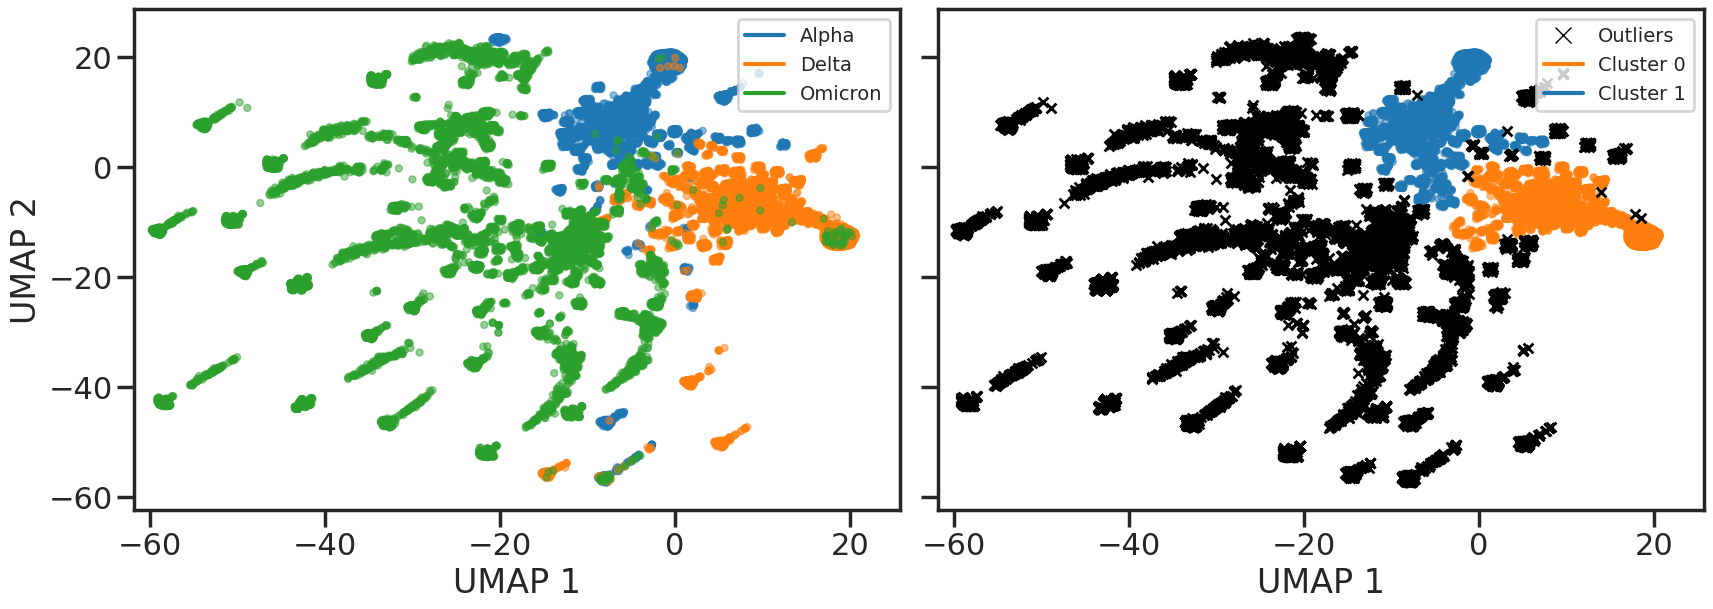

Predicted Clusters,-1,0,1
Ground Truth,,,
Alpha,6.71,0.26,93.03
Delta,5.64,93.51,0.85
Omicron,98.52,0.34,1.13


In [ ]:
rnd_seed = 0 # ONLY refers to the data, not the UMAP or TSNE random state

best = top5.iloc[0]
n_neighbors = int(best["n_neighbors"])
min_dist = best["min_dist"]
print(f"Seed 0 | UMAP | n_neighbors = {n_neighbors}, min_dist = {min_dist}")

plot_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/plots"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/parquets"
parquet_file = os.path.join(parquet_dir, version_dir, f"{version_prefix}.umap-nneighbors{n_neighbors}_mindist{min_dist}.parquet")

min_samples = int(best["best_min_samples"])
min_cluster_size = int(best["best_min_cluster_size"])
plot_df, truth_table_percent, save_as = get_hdbscan_values(parquet_file, min_samples, min_cluster_size)

unique_clusters = np.unique(plot_df["Cluster"])
non_noise_clusters = unique_clusters[unique_clusters != -1]
print(f"{len(non_noise_clusters)}: {non_noise_clusters}") # use this for cluster_color_palette_order if you want to set it

# Call the function
plot_groundtruth_prediction_1x2(
    plot_df, save_as, 
    plot_dir=os.path.join(plot_dir, version_dir),
    x_min_width_buffer=2, x_max_width_buffer=5, y_min_width_buffer=5, y_max_width_buffer=5, 
    color_map="tab10", 
    cluster_color_palette_order=[1, 0]
)
display(truth_table_percent)

### Best result within each UMAP setting, based on ari_noise_score, ARI, and SC

In [12]:
summary_df = (
    scored_results_df
    .sort_values(
        by=["ari_noise_score", "ari", "silhouette"],
        ascending=[False, False, False]
    )
    .groupby(["n_neighbors", "min_dist"], as_index=False)
    .first()
    .rename(columns={
        "ari": "best_ari",
        "silhouette": "best_silhouette",
        "n_clusters": "best_n_clusters",
        "noise_fraction": "best_noise_fraction",
        "ari_noise_score": "best_ari_noise_score",
        "ari_noise_silhouette_score": "best_ari_noise_silhouette_score",
        "ari_noise_silhouette_clusterct_score": "best_ari_noise_silhouette_clusterct_score",
        "min_samples": "best_min_samples",
        "min_cluster_size": "best_min_cluster_size",
    })
)

print("Best overall UMAP + HDBSCAN settings (top 5):")
top5 = (
    summary_df
    .sort_values(
        by=["best_ari_noise_score", "best_ari", "best_silhouette"],
        ascending=[False, False, False]
    )
    .head(5)
    .reset_index(drop=True)
)
display(top5)

Best overall UMAP + HDBSCAN settings (top 5):


,n_neighbors,min_dist,best_min_samples,best_min_cluster_size,best_ari,best_noise_fraction,best_silhouette,best_n_clusters,best_ari_noise_score,best_ari_noise_silhouette_score,best_ari_noise_silhouette_clusterct_score
0,100,0.50,100,2500,0.692709,0.161012,0.744328,6,0.487599,0.425266,9.488964e-02
1,75,0.50,10,15000,0.494546,0.015176,0.517552,2,0.479650,0.363947,2.207448e-01
2,100,0.00,10,1000,0.514186,0.038550,0.530230,15,0.475306,0.363663,9.014317e-04
3,100,0.75,25,2500,0.663662,0.154926,0.729742,6,0.473954,0.409909,9.146303e-02
4,50,0.00,25,250,0.497638,0.036784,0.549308,36,0.461701,0.357659,2.441238e-08


Seed 0 | UMAP | n_neighbors = 100, min_dist = 0.5
min_samples = 100, min_cluster_size = 2500: ARI = 0.69, Silhouette = 0.53, Clusters = 6, Noise = 16.10%
6: [0 1 2 3 4 5]


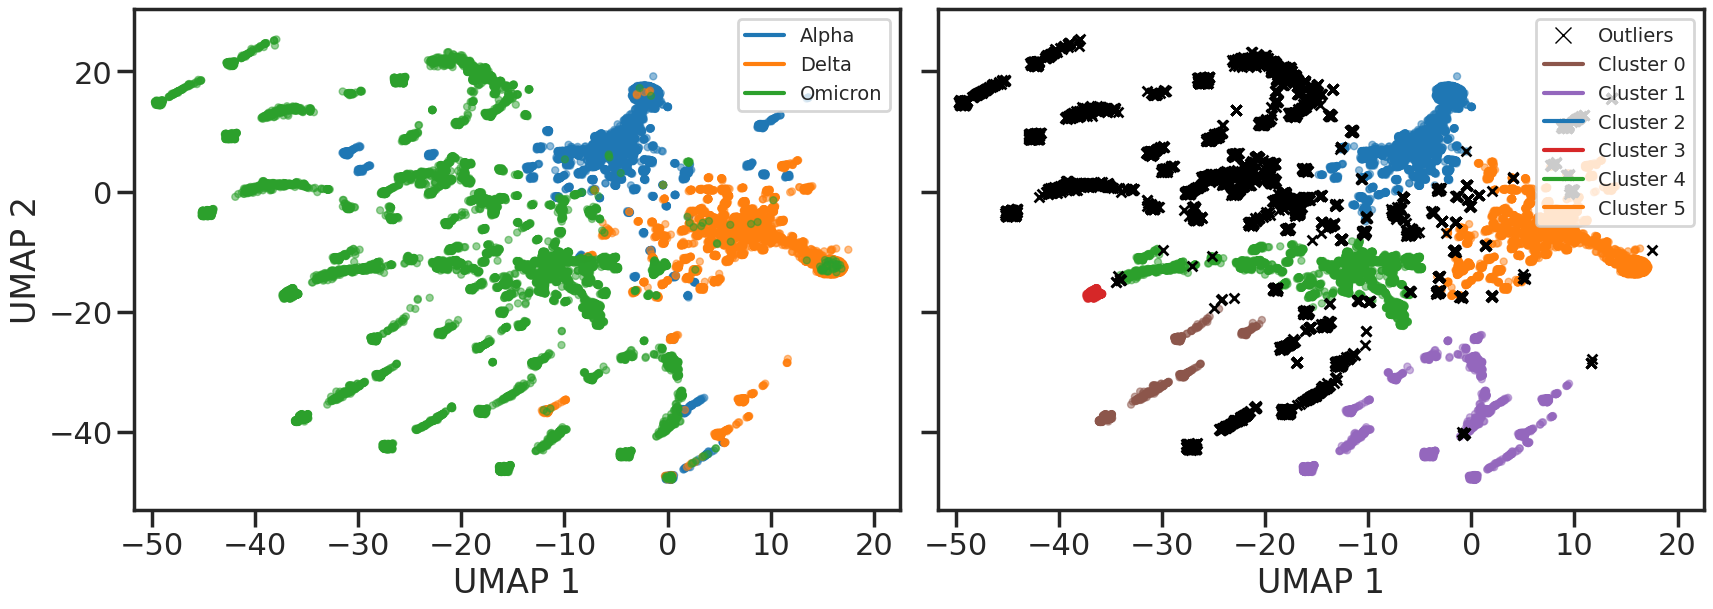

Predicted Clusters,-1,0,1,2,3,4,5
Ground Truth,,,,,,,
Alpha,4.09,0.0,2.93,91.13,0.00,0.12,1.73
Delta,1.24,0.0,3.67,0.04,0.00,0.14,94.91
Omicron,42.98,11.7,13.34,0.65,13.84,16.19,1.30


In [ ]:
rnd_seed = 0 # ONLY refers to the data, not the UMAP or TSNE random state

best = top5.iloc[0]
n_neighbors = int(best["n_neighbors"])
min_dist = best["min_dist"]
print(f"Seed 0 | UMAP | n_neighbors = {n_neighbors}, min_dist = {min_dist}")

plot_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/plots"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/parquets"
parquet_file = os.path.join(parquet_dir, version_dir, f"{version_prefix}.umap-nneighbors{n_neighbors}_mindist{min_dist}.parquet")

min_samples = int(best["best_min_samples"])
min_cluster_size = int(best["best_min_cluster_size"])
plot_df, truth_table_percent, save_as = get_hdbscan_values(parquet_file, min_samples, min_cluster_size)

save_as.replace(".parquet", ".best_ari_noise_score.parquet")

unique_clusters = np.unique(plot_df["Cluster"])
non_noise_clusters = unique_clusters[unique_clusters != -1]
print(f"{len(non_noise_clusters)}: {non_noise_clusters}") # use this for cluster_color_palette_order if you want to set it

# Call the function
plot_groundtruth_prediction_1x2(
    plot_df, save_as, 
    plot_dir=os.path.join(plot_dir, version_dir),
    x_min_width_buffer=2, x_max_width_buffer=5, y_min_width_buffer=5, y_max_width_buffer=5, 
    color_map="tab10", 
    cluster_color_palette_order=[5, 4, 0, 3, 2, 1]
)
display(truth_table_percent)

### Best result within each UMAP setting, based on ari_noise_silhouette_score, ARI, and SC

In [14]:
summary_df = (
    scored_results_df
    .sort_values(
        by=["ari_noise_silhouette_score", "ari", "silhouette"],
        ascending=[False, False, False]
    )
    .groupby(["n_neighbors", "min_dist"], as_index=False)
    .first()
    .rename(columns={
        "ari": "best_ari",
        "silhouette": "best_silhouette",
        "n_clusters": "best_n_clusters",
        "noise_fraction": "best_noise_fraction",
        "ari_noise_score": "best_ari_noise_score",
        "ari_noise_silhouette_score": "best_ari_noise_silhouette_score",
        "ari_noise_silhouette_clusterct_score": "best_ari_noise_silhouette_clusterct_score",
        "min_samples": "best_min_samples",
        "min_cluster_size": "best_min_cluster_size",
    })
)

print("Best overall UMAP + HDBSCAN settings (top 5):")
top5 = (
    summary_df
    .sort_values(
        by=["best_ari_noise_silhouette_score", "best_ari", "best_silhouette"],
        ascending=[False, False, False]
    )
    .head(5)
    .reset_index(drop=True)
)
display(top5)

Best overall UMAP + HDBSCAN settings (top 5):


,n_neighbors,min_dist,best_min_samples,best_min_cluster_size,best_ari,best_noise_fraction,best_silhouette,best_n_clusters,best_ari_noise_score,best_ari_noise_silhouette_score,best_ari_noise_silhouette_clusterct_score
0,100,0.50,100,2500,0.692709,0.161012,0.744328,6,0.487599,0.425266,9.488964e-02
1,100,0.75,1000,2500,0.668578,0.179675,0.840036,5,0.449908,0.413923,1.522738e-01
2,75,0.10,10,5000,0.779833,0.249528,0.841057,3,0.439208,0.404304,4.043038e-01
3,75,0.00,50,250,0.500730,0.044862,0.690335,38,0.456810,0.386081,9.694490e-09
4,100,0.00,25,250,0.501761,0.026833,0.617338,38,0.475195,0.384275,9.649148e-09


Seed 0 | UMAP | n_neighbors = 100, min_dist = 0.5


min_samples = 100, min_cluster_size = 2500: ARI = 0.69, Silhouette = 0.53, Clusters = 6, Noise = 16.10%
6: [0 1 2 3 4 5]


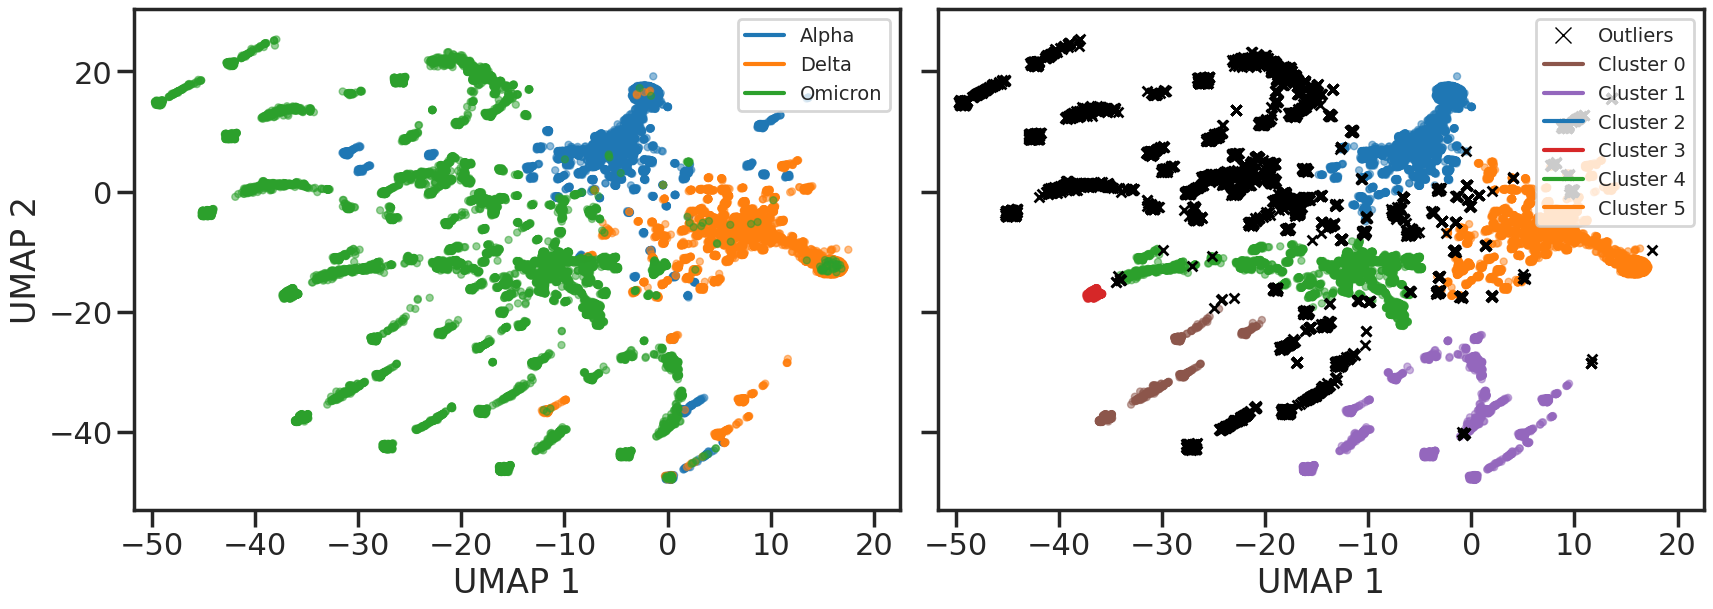

Predicted Clusters,-1,0,1,2,3,4,5
Ground Truth,,,,,,,
Alpha,4.09,0.0,2.93,91.13,0.00,0.12,1.73
Delta,1.24,0.0,3.67,0.04,0.00,0.14,94.91
Omicron,42.98,11.7,13.34,0.65,13.84,16.19,1.30


In [ ]:
rnd_seed = 0 # ONLY refers to the data, not the UMAP or TSNE random state

best = top5.iloc[0]
n_neighbors = int(best["n_neighbors"])
min_dist = best["min_dist"]
print(f"Seed 0 | UMAP | n_neighbors = {n_neighbors}, min_dist = {min_dist}")

plot_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/plots"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/parquets"
parquet_file = os.path.join(parquet_dir, version_dir, f"{version_prefix}.umap-nneighbors{n_neighbors}_mindist{min_dist}.parquet")

min_samples = int(best["best_min_samples"])
min_cluster_size = int(best["best_min_cluster_size"])
plot_df, truth_table_percent, save_as = get_hdbscan_values(parquet_file, min_samples, min_cluster_size)

save_as.replace(".parquet", ".best_ari_noise_silhouette_score.parquet")

unique_clusters = np.unique(plot_df["Cluster"])
non_noise_clusters = unique_clusters[unique_clusters != -1]
print(f"{len(non_noise_clusters)}: {non_noise_clusters}") # use this for cluster_color_palette_order if you want to set it

# Call the function
plot_groundtruth_prediction_1x2(
    plot_df, save_as, 
    plot_dir=os.path.join(plot_dir, version_dir),
    x_min_width_buffer=2, x_max_width_buffer=5, y_min_width_buffer=5, y_max_width_buffer=5, 
    color_map="tab10", 
    cluster_color_palette_order=[5, 4, 0, 3, 2, 1]
)
display(truth_table_percent)

### Best result within each UMAP setting, based on ari_noise_silhouette_clusterct_score, ARI, and SC

In [16]:
summary_df = (
    scored_results_df
    .sort_values(
        by=["ari_noise_silhouette_clusterct_score", "ari", "silhouette"],
        ascending=[False, False, False]
    )
    .groupby(["n_neighbors", "min_dist"], as_index=False)
    .first()
    .rename(columns={
        "ari": "best_ari",
        "silhouette": "best_silhouette",
        "n_clusters": "best_n_clusters",
        "noise_fraction": "best_noise_fraction",
        "ari_noise_score": "best_ari_noise_score",
        "ari_noise_silhouette_score": "best_ari_noise_silhouette_score",
        "ari_noise_silhouette_clusterct_score": "best_ari_noise_silhouette_clusterct_score",
        "min_samples": "best_min_samples",
        "min_cluster_size": "best_min_cluster_size",
    })
)

print("Best overall UMAP + HDBSCAN settings (top 5):")
top5 = (
    summary_df
    .sort_values(
        by=["best_ari_noise_silhouette_clusterct_score", "best_ari", "best_silhouette"],
        ascending=[False, False, False]
    )
    .head(5)
    .reset_index(drop=True)
)
display(top5)

Best overall UMAP + HDBSCAN settings (top 5):


,n_neighbors,min_dist,best_min_samples,best_min_cluster_size,best_ari,best_noise_fraction,best_silhouette,best_n_clusters,best_ari_noise_score,best_ari_noise_silhouette_score,best_ari_noise_silhouette_clusterct_score
0,75,0.10,10,5000,0.779833,0.249528,0.841057,3,0.439208,0.404304,0.404304
1,100,0.15,10,5000,0.717263,0.268297,0.866166,3,0.384014,0.358317,0.358317
2,75,0.75,10,5000,0.588975,0.175372,0.716556,3,0.400510,0.343749,0.343749
3,100,1.00,50,2500,0.764567,0.340445,0.924432,3,0.332596,0.320029,0.320029
4,100,0.25,1000,2500,0.673589,0.289513,0.807598,3,0.340022,0.307311,0.307311


Seed 0 | UMAP | n_neighbors = 75, min_dist = 0.1


min_samples = 10, min_cluster_size = 5000: ARI = 0.78, Silhouette = 0.49, Clusters = 3, Noise = 24.95%
3: [0 1 2]


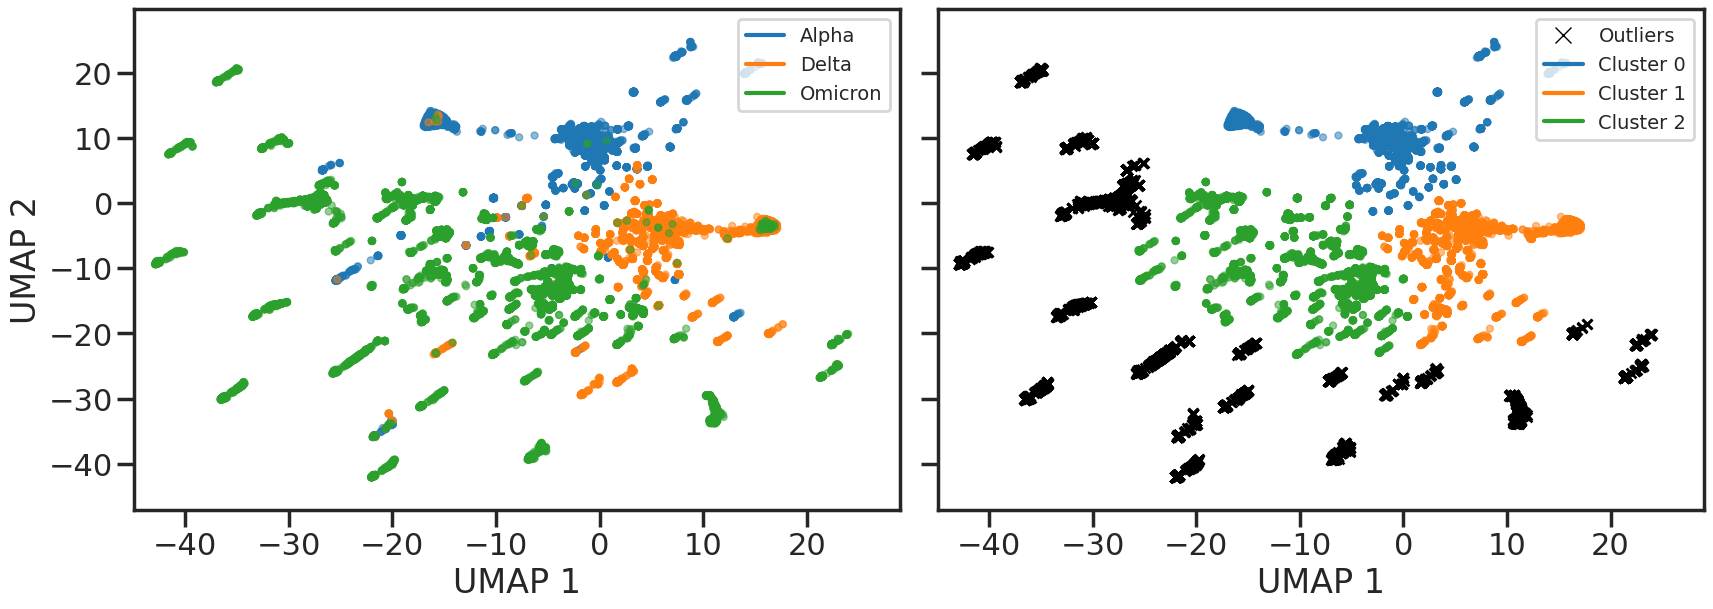

Predicted Clusters,-1,0,1,2
Ground Truth,,,,
Alpha,2.07,94.31,0.63,2.99
Delta,3.90,0.39,94.39,1.31
Omicron,68.89,0.10,2.82,28.19


In [ ]:
rnd_seed = 0 # ONLY refers to the data, not the UMAP or TSNE random state

best = top5.iloc[0]
n_neighbors = int(best["n_neighbors"])
min_dist = best["min_dist"]
print(f"Seed 0 | UMAP | n_neighbors = {n_neighbors}, min_dist = {min_dist}")

plot_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/plots"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/parquets"
parquet_file = os.path.join(parquet_dir, version_dir, f"{version_prefix}.umap-nneighbors{n_neighbors}_mindist{min_dist}.parquet")

min_samples = int(best["best_min_samples"])
min_cluster_size = int(best["best_min_cluster_size"])
plot_df, truth_table_percent, save_as = get_hdbscan_values(parquet_file, min_samples, min_cluster_size)

save_as.replace(".parquet", ".best_ari_noise_silhouette_clusterct_score.parquet")

unique_clusters = np.unique(plot_df["Cluster"])
non_noise_clusters = unique_clusters[unique_clusters != -1]
print(f"{len(non_noise_clusters)}: {non_noise_clusters}") # use this for cluster_color_palette_order if you want to set it

# Call the function
plot_groundtruth_prediction_1x2(
    plot_df, save_as, 
    plot_dir=os.path.join(plot_dir, version_dir),
    x_min_width_buffer=2, x_max_width_buffer=5, y_min_width_buffer=5, y_max_width_buffer=5, 
    color_map="tab10", 
    cluster_color_palette_order=[0, 1, 2]
)
display(truth_table_percent)

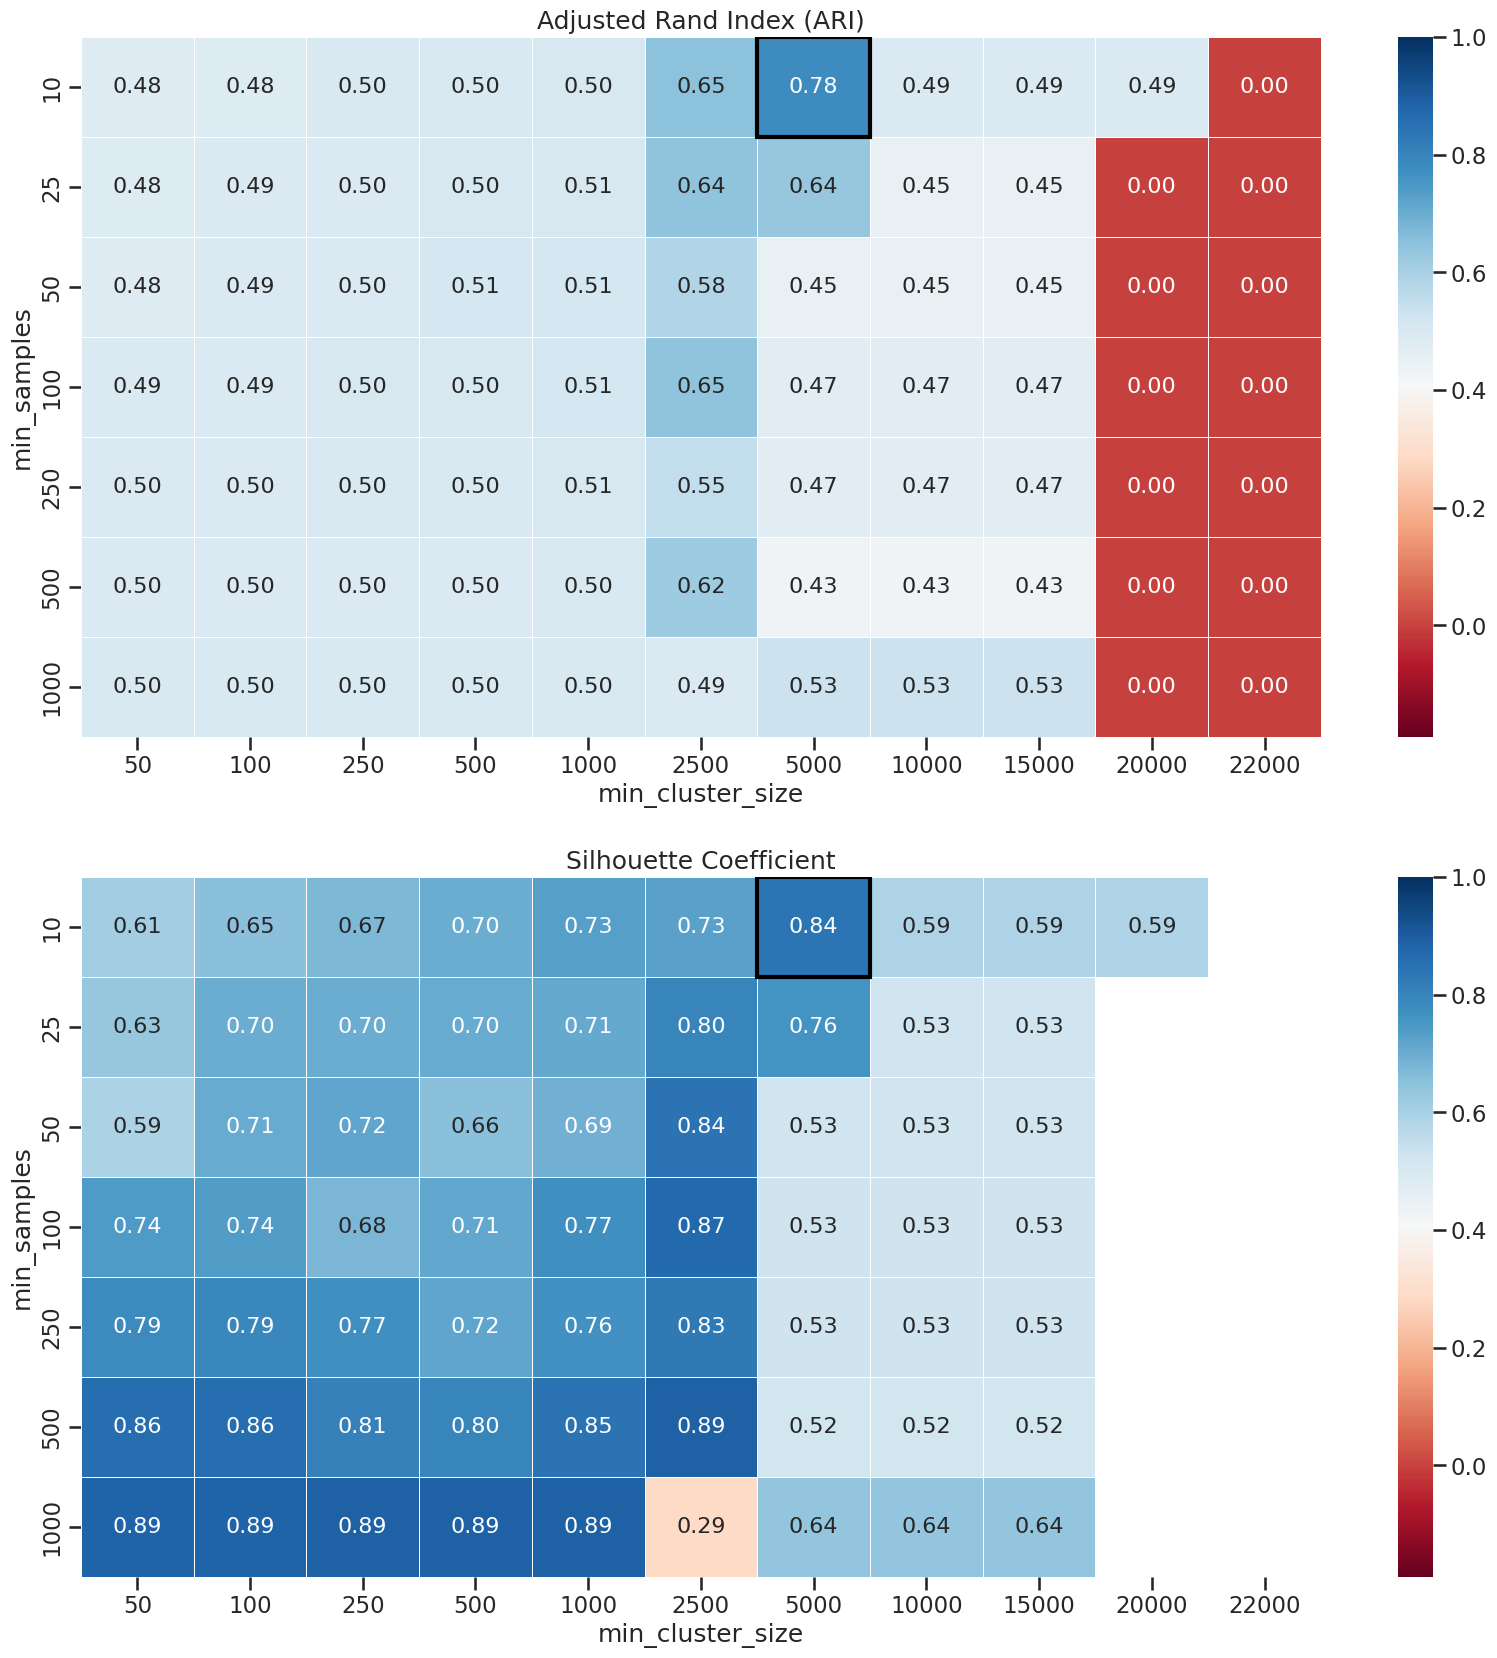

In [18]:
best_df = scored_results_df[
    (scored_results_df["n_neighbors"] == n_neighbors) &
    (scored_results_df["min_dist"] == min_dist)
].copy()

ari_sc_heatmap(
    best_df,
    parquet_file,  
    plot_dir=os.path.join(plot_dir, version_dir),
)

In [19]:
# Cluster info
result = cluster_pango_lineage(plot_df, 5)

clusters = result['Cluster'].unique()
clustered_dataframes = split_dataframe_by_cluster(result)

for cluster in clusters:
    print(f"{clustered_dataframes[cluster]}\n")

   Cluster  Variant Pango lineage  Cluster %  Lineage %
0       -1  Omicron       BA.5.2*   9.549168  75.071361
1       -1  Omicron       BQ.1.1*   7.249622  83.952348
2       -1  Omicron          BA.2   6.977307  59.432990
3       -1  Omicron      XBB.1.5*   6.862330  95.454545
4       -1  Omicron       BA.1.1*   6.281392  58.943782

   Cluster Variant Pango lineage  Cluster %   Lineage %
0        0   Alpha        B.1.1*  97.219037   93.955207
1        0   Alpha           Q.3   0.907875   97.435897
2        0   Alpha           Q.4   0.530390   95.689655
3        0   Alpha           Q.1   0.487385   84.297521
4        0   Alpha           Q.2   0.114679  100.000000

   Cluster Variant Pango lineage  Cluster %  Lineage %
0        1   Delta          AY.4  12.894712  96.300138
1        1   Delta      B.1.617*   6.903417  92.897196
2        1   Delta        AY.122   6.171868  92.633773
3        1   Delta        AY.103   5.444949  94.762288
4        1   Delta         AY.43   4.537457  94.685

In [ ]:
cluster_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/clusters"

for cluster in clusters:
    print(cluster)
    cluster_df =  plot_df[plot_df["Cluster"] == cluster]
    print(cluster_df["Variant"].value_counts())

    save_as = f"{version_prefix}.umap-nneighbors{n_neighbors}_mindist{min_dist}.cluster{cluster}"
    cluster_df.to_csv(os.path.join(cluster_dir, version_dir, f"{save_as}.csv"), index=False)

-1
Variant
Omicron    15207
Delta        861
Alpha        457
Name: count, dtype: int64
0
Variant
Alpha      20818
Delta         87
Omicron       23
Name: count, dtype: int64
1
Variant
Delta      20837
Omicron      622
Alpha        139
Name: count, dtype: int64
2
Variant
Omicron    6223
Alpha       661
Delta       290
Name: count, dtype: int64


## Other random seeds
### ARI & SC 

In [ ]:
import pandas as pd

rnd_seed = 0
sweep_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/param_sweeps"

full_results_umap_df = pd.read_csv(os.path.join(sweep_dir, version_dir, f"{version_prefix}-umap_hdbscan-parameter_sweep.csv"))
scored_results_df = full_results_umap_df.copy()

In [ ]:
# Make sure ari between -1 and 1...
invalid_ari_mask = (
    scored_results_df["ari"].notna()
    & ~scored_results_df["ari"].between(-1, 1)
)

print("Invalid ari rows:", invalid_ari_mask.sum())
print("Rows before:", len(scored_results_df))

# Drop invalid rows
scored_results_df = scored_results_df.loc[~invalid_ari_mask].copy()

print("Rows after:", len(scored_results_df))

# Make sure silhouette between -1 and 1...
invalid_silhouette_mask = (
    scored_results_df["silhouette"].notna()
    & ~scored_results_df["silhouette"].between(-1, 1)
)

print("Invalid silhouette rows:", invalid_silhouette_mask.sum())
print("Rows before:", len(scored_results_df))

# Drop invalid rows
scored_results_df = scored_results_df.loc[~invalid_silhouette_mask].copy()

print("Rows after:", len(scored_results_df))

In [ ]:
summary_df = (
    scored_results_df
    .sort_values(by=["ari", "silhouette"], ascending=[False, False])
    .groupby(["n_neighbors", "min_dist"], as_index=False)
    .first()
    .rename(columns={
        "ari": "best_ari",
        "silhouette": "best_silhouette",
        "n_clusters": "best_n_clusters",
        "noise_fraction": "best_noise_fraction",
        "ari_noise_score": "best_ari_noise_score",
        "ari_noise_silhouette_score": "best_ari_noise_silhouette_score",
        "ari_noise_silhouette_clusterct_score": "best_ari_noise_silhouette_clusterct_score",
        "min_samples": "best_min_samples",
        "min_cluster_size": "best_min_cluster_size",
    })
)

print(f"Best overall UMAP + HDBSCAN settings (top 5):")
top5 = (
    summary_df.sort_values(
        by=["best_ari", "best_silhouette"],
        ascending=[False, False]
    ).head(5)
).reset_index(drop=True)
display(top5)

In [ ]:
rnd_seed = 0 # ONLY refers to the data, not the UMAP or TSNE random state

best = top5.iloc[0]
n_neighbors = int(best["n_neighbors"])
min_dist = best["min_dist"]
print(f"Seed 0 | UMAP | n_neighbors = {n_neighbors}, min_dist = {min_dist}")

plot_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/plots"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/rbd/parquets"
parquet_file = os.path.join(parquet_dir, version_dir, f"{version_prefix}.umap-nneighbors{n_neighbors}_mindist{min_dist}.parquet")

min_samples = int(best["best_min_samples"])
min_cluster_size = int(best["best_min_cluster_size"])
plot_df, truth_table_percent, save_as = get_hdbscan_values(parquet_file, min_samples, min_cluster_size)

unique_clusters = np.unique(plot_df["Cluster"])
non_noise_clusters = unique_clusters[unique_clusters != -1]
print(f"{len(non_noise_clusters)}: {non_noise_clusters}") # use this for cluster_color_palette_order if you want to set it

# Call the function
plot_groundtruth_prediction_1x2(
    plot_df, save_as, 
    plot_dir=os.path.join(plot_dir, version_dir),
    x_min_width_buffer=2, x_max_width_buffer=5, y_min_width_buffer=5, y_max_width_buffer=5, 
    color_map="tab10", 
    cluster_color_palette_order=[1, 0]
)
display(truth_table_percent)